In [1]:
!pip install -q tensorflow pandas matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers


In [3]:
# Load CSV
url = "https://raw.githubusercontent.com/m-mahdavi/teaching/refs/heads/main/datasets/mnist.csv"
df = pd.read_csv(url)

# Separate features and labels (label is in first column)
df.rename(columns={df.columns[0]: "label"}, inplace=True)

X = df.drop("label", axis=1)
y = df["label"]


In [8]:
# Normalize images between [-1, 1] for GANs
X = (X.astype(np.float32) - 127.5) / 127.5
X = X.reshape(-1, 28, 28, 1)  # reshape for Conv2D layers


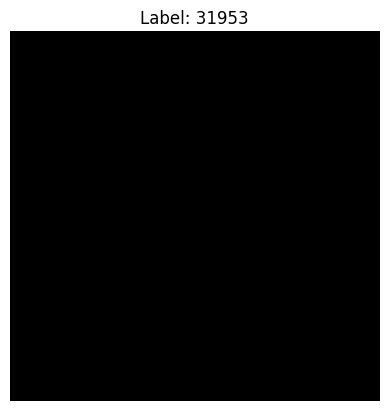

In [9]:
# Show sample
plt.imshow((X[0].reshape(28, 28) + 1) / 2, cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

In [10]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh'),
    ])
    return model


In [11]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[28,28,1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1),
    ])
    return model


In [12]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator = build_generator()
discriminator = build_discriminator()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
BATCH_SIZE = 256
EPOCHS = 50
NOISE_DIM = 100
NUM_EXAMPLES_TO_GENERATE = 16

seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])
train_dataset = tf.data.Dataset.from_tensor_slices(X).shuffle(60000).batch(BATCH_SIZE)


Epoch 1/50 completed


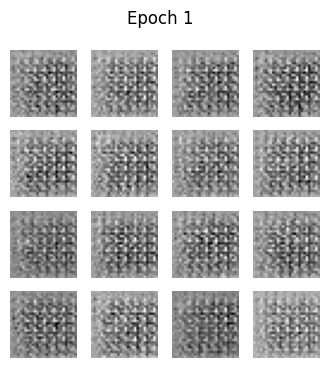

Epoch 2/50 completed


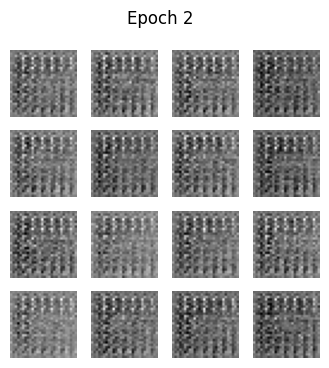

Epoch 3/50 completed


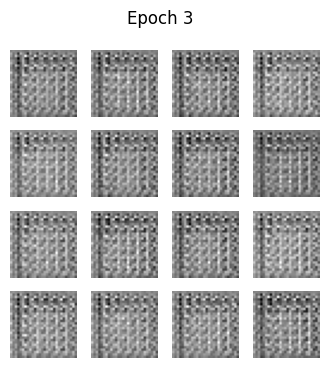

Epoch 4/50 completed


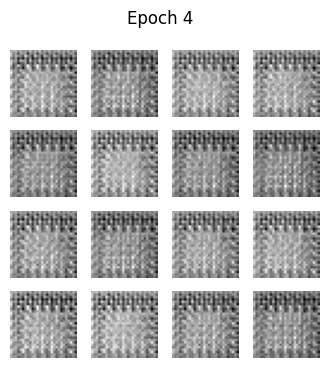

Epoch 5/50 completed


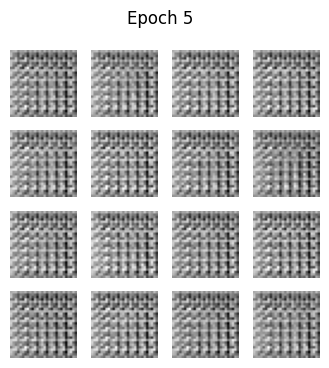

Epoch 6/50 completed


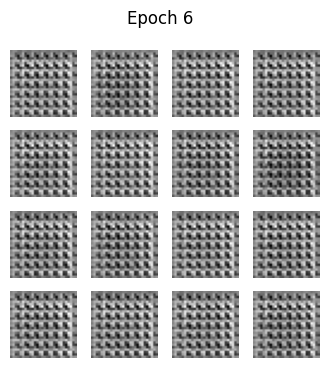

Epoch 7/50 completed


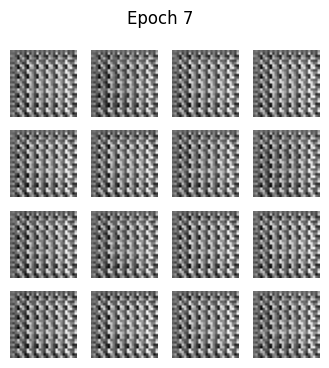

Epoch 8/50 completed


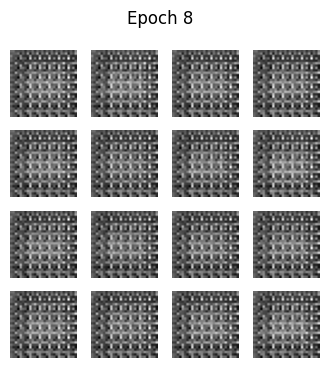

Epoch 9/50 completed


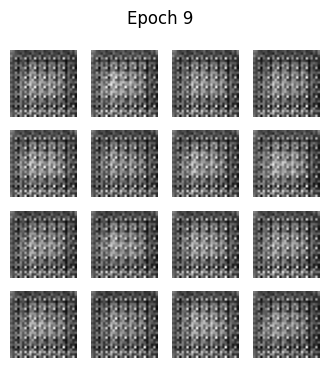

Epoch 10/50 completed


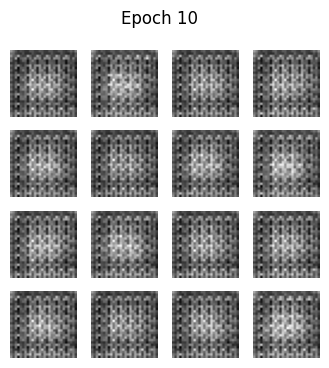

Epoch 11/50 completed


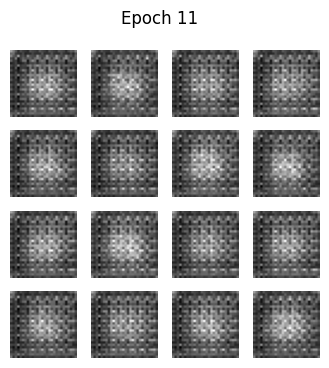

Epoch 12/50 completed


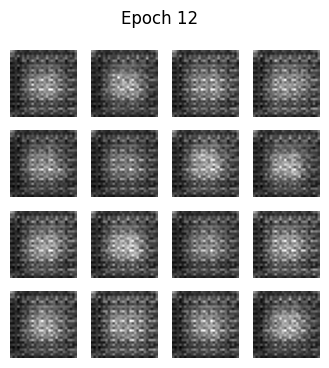

Epoch 13/50 completed


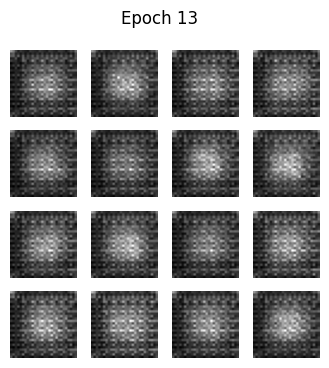

Epoch 14/50 completed


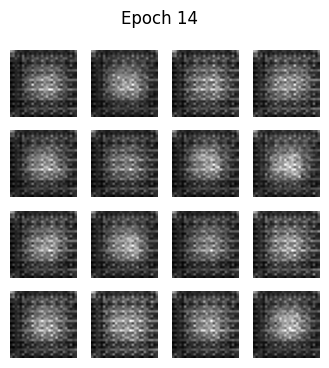

Epoch 15/50 completed


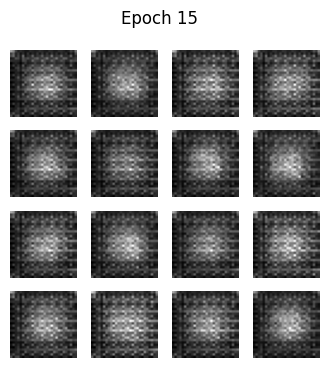

Epoch 16/50 completed


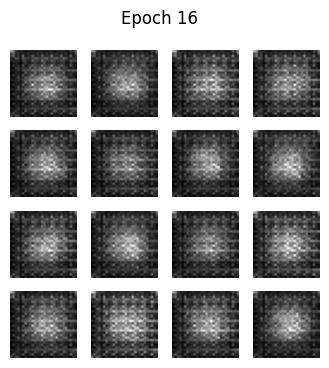

Epoch 17/50 completed


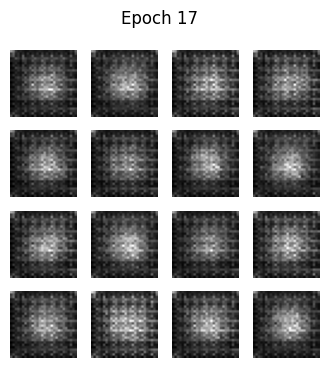

Epoch 18/50 completed


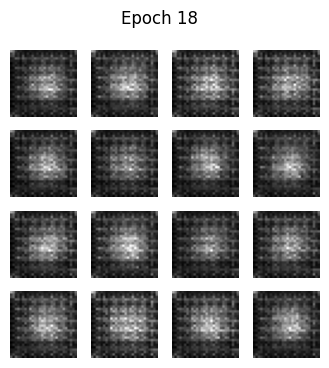

Epoch 19/50 completed


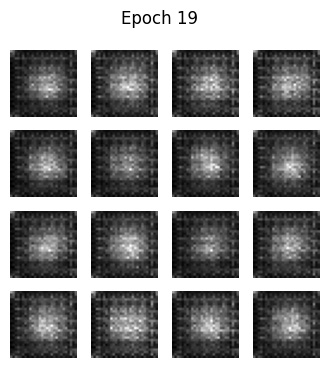

Epoch 20/50 completed


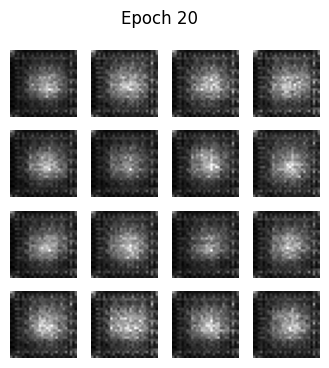

Epoch 21/50 completed


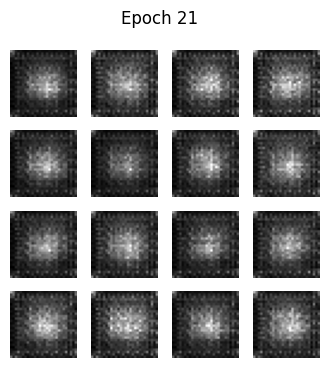

Epoch 22/50 completed


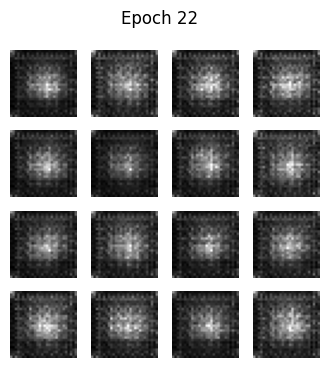

Epoch 23/50 completed


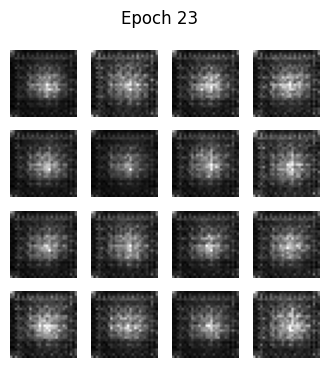

Epoch 24/50 completed


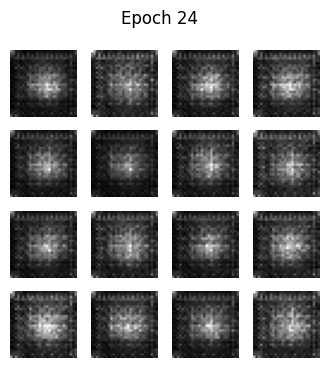

Epoch 25/50 completed


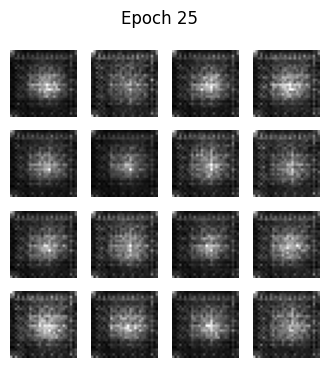

Epoch 26/50 completed


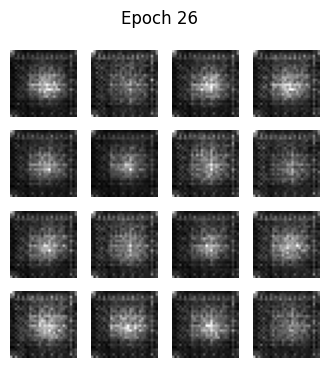

Epoch 27/50 completed


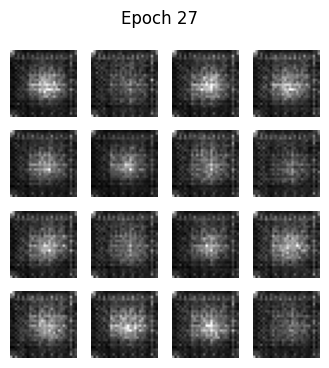

Epoch 28/50 completed


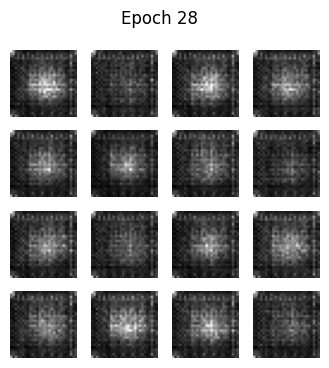

Epoch 29/50 completed


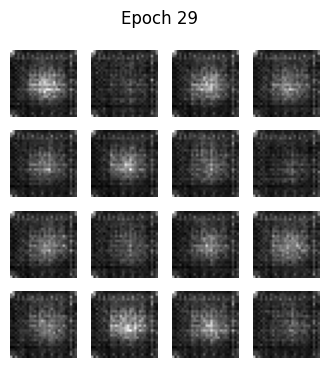

Epoch 30/50 completed


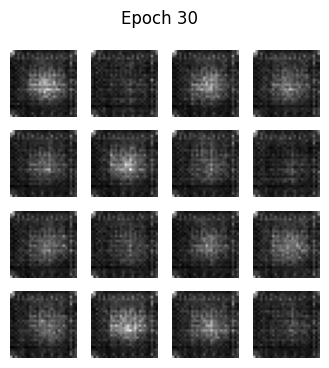

Epoch 31/50 completed


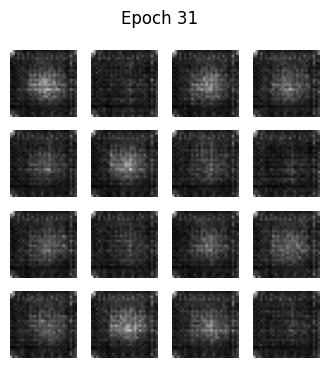

Epoch 32/50 completed


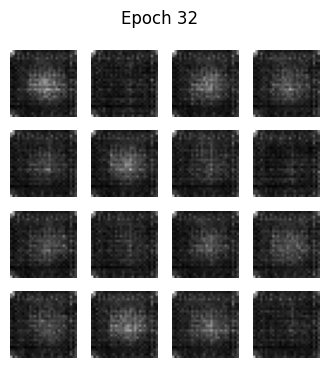

Epoch 33/50 completed


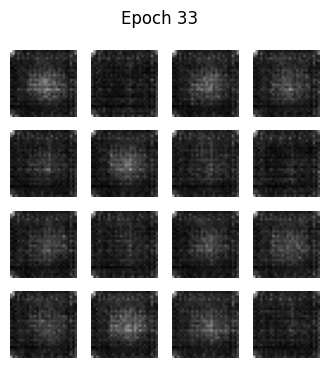

Epoch 34/50 completed


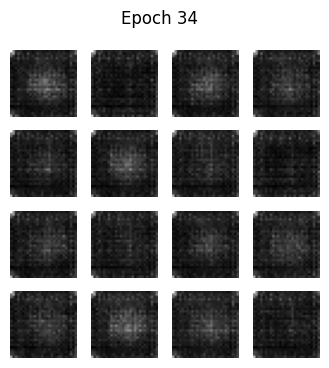

Epoch 35/50 completed


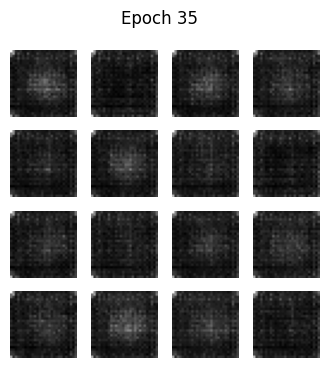

Epoch 36/50 completed


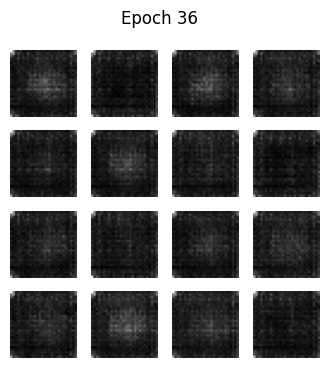

Epoch 37/50 completed


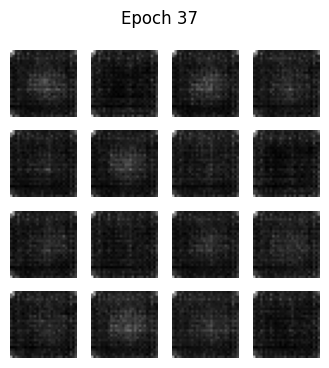

Epoch 38/50 completed


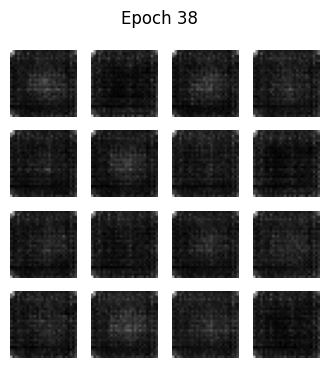

Epoch 39/50 completed


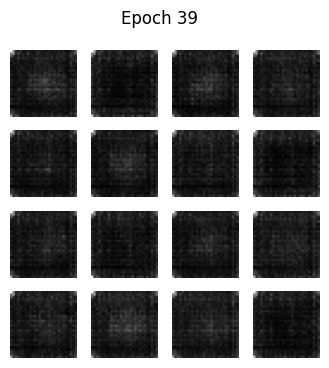

Epoch 40/50 completed


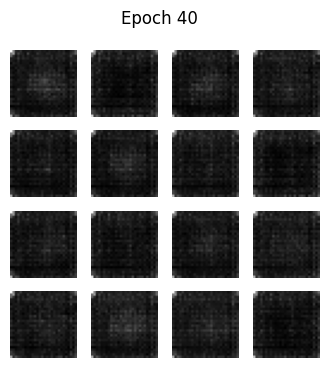

Epoch 41/50 completed


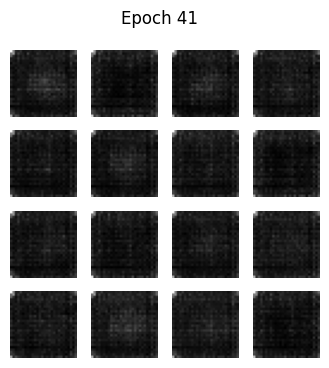

Epoch 42/50 completed


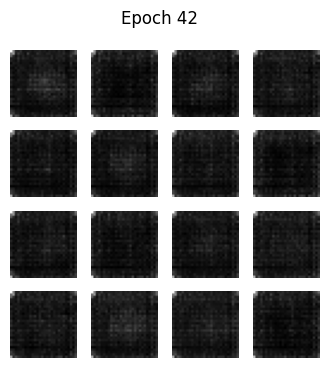

Epoch 43/50 completed


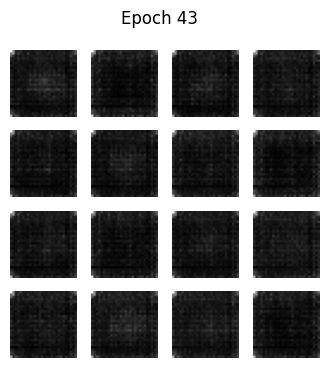

Epoch 44/50 completed


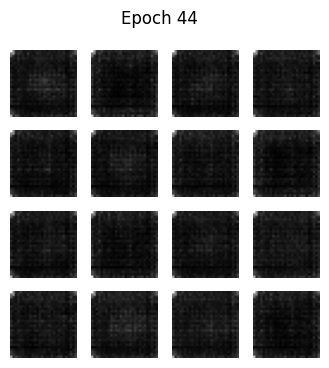

Epoch 45/50 completed


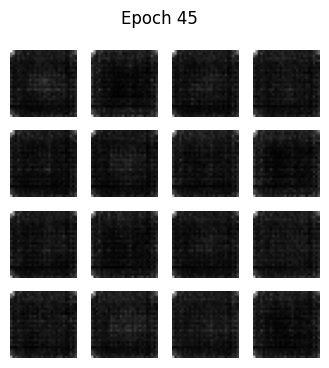

Epoch 46/50 completed


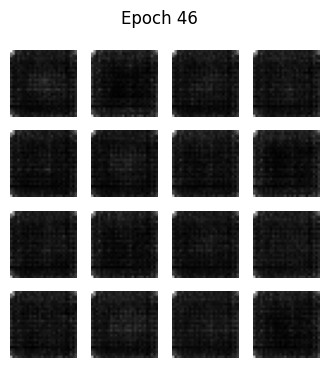

Epoch 47/50 completed


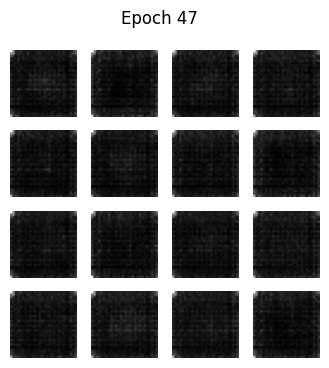

Epoch 48/50 completed


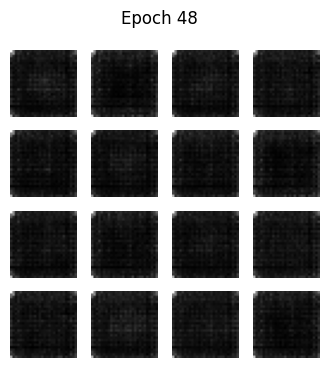

Epoch 49/50 completed


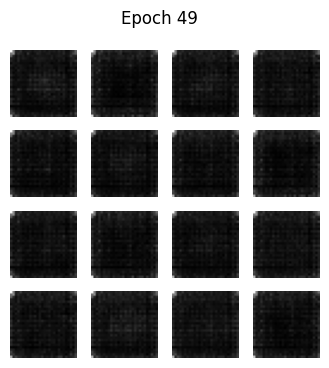

Epoch 50/50 completed


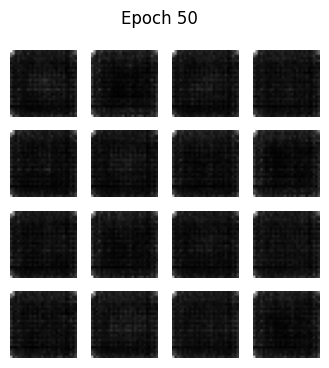

In [14]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)
        print(f'Epoch {epoch+1}/{epochs} completed')
        generate_and_plot_images(generator, epoch+1)

def generate_and_plot_images(model, epoch):
    predictions = model(seed, training=False)
    fig = plt.figure(figsize=(4,4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

train(train_dataset, EPOCHS)


In [15]:
# Generator summary and key methods
generator.summary()
print("Generator input shape:", generator.input_shape)
print("Generator output shape:", generator.output_shape)
print("Generator layers:", [layer.name for layer in generator.layers])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Generator input shape: (None, 100)
Generator output shape: (None, 28, 28, 1)
Generator layers: ['dense', 'batch_normalization', 'leaky_re_lu', 'reshape', 'conv2d_transpose', 'batch_normalization_1', 'leaky_re_lu_1', 'conv2d_transpose_1', 'batch_normalization_2', 'leaky_re_lu_2', 'conv2d_transpose_2']
